<a href="https://colab.research.google.com/github/vitor-thompson/Python-para-financas-investimento-e-analise-de-dados./blob/main/redimento_do_portifolio_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1036/593337360.py:68: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_prices = yf.download(tickers_to_download, start=start_analysis)['Close']
[*********************100%***********************]  8 of 8 completed


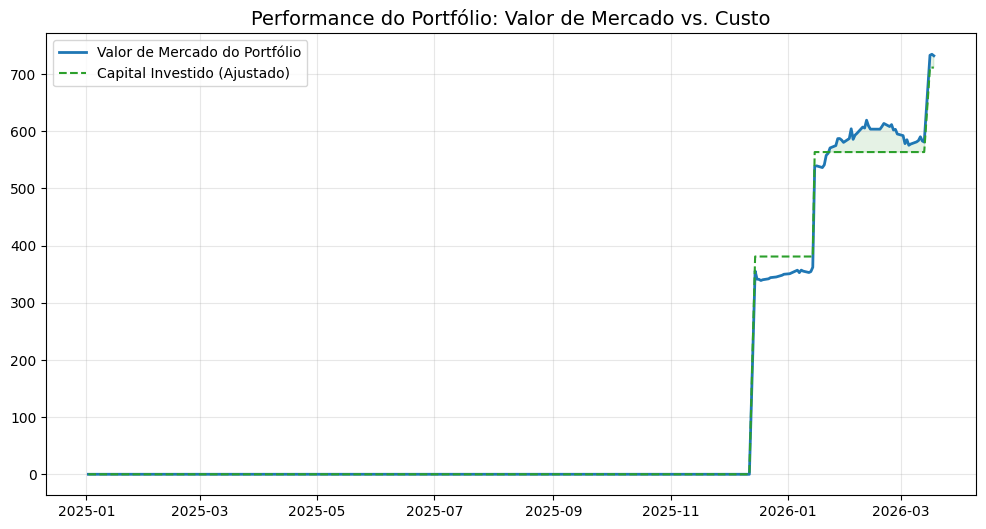

Patrimônio Atual: R$ 732.08
Total Investido: R$ 711.43
Rentabilidade: 2.90%


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
import copy

# --- CONFIGURAÇÕES ---
assets = ['ITUB4.SA','ITSA4.SA','TAEE11.SA','SBSP3.SA','VALE3.SA','PETR4.SA', 'RADL3.SA','WEGE3.SA','BBSE3.SA','RAIL3.SA','B3SA3.SA']
start_analysis = '2025-01-01' # Otimizado: focado no período das compras

# --- DADOS DE ENTRADA ---
all_purchases = {
    'ITUB4.SA': [{"data": "2025-12-15", "valor": 40.14, "quantidade": 1}, {"data": "2026-03-16", "valor": 43.07, "quantidade": 5}],
    'ITSA4.SA': [{"data": "2025-12-15", "valor": 11.94, "quantidade": 2}, {"data": "2026-01-15", "valor": 12.09, "quantidade": 1}, {"data": "2026-03-16", "valor": 13.42, "quantidade": 5}],
    'TAEE11.SA': [{"data": "2025-12-15", "valor": 42.99, "quantidade": 2}, {"data": "2026-01-15", "valor": 39.99, "quantidade": 1}, {"data": "2026-02-19", "valor": 44.27, "quantidade": 1}],
    'PETR4.SA': [{"data": "2025-12-15", "valor": 31.91, "quantidade": 3}, {"data": "2026-01-15", "valor": 31.66, "quantidade": 1}, {"data": "2026-02-19", "valor": 37.74, "quantidade": 1}],
    'RADL3.SA': [{"data": "2025-12-15", "valor": 25.34, "quantidade": 4}, {"data": "2026-01-15", "valor": 24.23, "quantidade": 2}, {"data": "2026-02-19", "valor": 26.73, "quantidade": 1}],
    'WEGE3.SA': [{"data": "2025-12-15", "valor": 49.36, "quantidade": 2}, {"data": "2026-01-15", "valor": 46.85, "quantidade": 1}, {"data": "2026-02-19", "valor": 51.62, "quantidade": 1}],
    'BBSE3.SA': [{"data": "2026-03-16", "valor": 34.90, "quantidade": 3}]
}

all_sales = {
    'TAEE11.SA': [{'data': '2026-03-16', 'valor': 42.77, 'quantidade': 2}],
    'PETR4.SA': [{'data': '2026-03-16', 'valor': 45.50, 'quantidade': 2}],
    'WEGE3.SA': [{'data': '2026-03-16', 'valor': 45.62, 'quantidade': 2}],
    'ITUB4.SA' :[{"data": "2026-03-17", "valor": 42.97, "quantidade": 5}]
}

# --- 1. PROCESSAMENTO FIFO ---
portfolio_final = {}
purchases_working = copy.deepcopy(all_purchases)

for ticker, sales in all_sales.items():
    if ticker in purchases_working:
        for sale in sales:
            qty_to_reduce = sale['quantidade']
            # Ordena por data (FIFO)
            purchases_working[ticker].sort(key=lambda x: x['data'])

            remaining_purchases = []
            for p in purchases_working[ticker]:
                if qty_to_reduce <= 0:
                    remaining_purchases.append(p)
                elif p['quantidade'] > qty_to_reduce:
                    p['quantidade'] -= qty_to_reduce
                    qty_to_reduce = 0
                    remaining_purchases.append(p)
                else:
                    qty_to_reduce -= p['quantidade']
            purchases_working[ticker] = remaining_purchases

# Consolidação do Preço Médio e Quantidade Atual
for ticker, buys in purchases_working.items():
    if buys:
        total_qty = sum(b['quantidade'] for b in buys)
        total_cost = sum(b['quantidade'] * b['valor'] for b in buys)
        earliest_date = min(datetime.strptime(b['data'], '%Y-%m-%d') for b in buys)
        portfolio_final[ticker] = {
            'purchase_date': earliest_date,
            'avg_price': total_cost / total_qty,
            'quantity': total_qty,
            'total_invested': total_cost
        }

# --- 2. DOWNLOAD DE DADOS OTIMIZADO ---
tickers_to_download = list(portfolio_final.keys()) + ['^BVSP']
df_prices = yf.download(tickers_to_download, start=start_analysis)['Close']

# --- 3. CÁLCULO DA EVOLUÇÃO ---
# Criamos um DataFrame para o valor total diário e investimento acumulado
portfolio_evolution = pd.DataFrame(index=df_prices.index)
portfolio_evolution['Total_Value'] = 0.0
portfolio_evolution['Total_Invested'] = 0.0

for ticker, info in portfolio_final.items():
    mask = portfolio_evolution.index >= info['purchase_date']
    portfolio_evolution.loc[mask, 'Total_Value'] += df_prices.loc[mask, ticker] * info['quantity']
    portfolio_evolution.loc[mask, 'Total_Invested'] += info['total_invested']

# --- 4. VISUALIZAÇÃO ---


plt.figure(figsize=(12, 6))
plt.plot(portfolio_evolution['Total_Value'], label='Valor de Mercado do Portfólio', color='#1f77b4', lw=2)
plt.plot(portfolio_evolution['Total_Invested'], label='Capital Investido (Ajustado)', color='#2ca02c', linestyle='--')
plt.fill_between(portfolio_evolution.index, portfolio_evolution['Total_Value'], portfolio_evolution['Total_Invested'],
                 where=(portfolio_evolution['Total_Value'] >= portfolio_evolution['Total_Invested']), color='green', alpha=0.1)
plt.title('Performance do Portfólio: Valor de Mercado vs. Custo', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 5. RESULTADOS ---
final_val = portfolio_evolution['Total_Value'].iloc[-1]
invested_val = portfolio_evolution['Total_Invested'].iloc[-1]
profit_pct = ((final_val - invested_val) / invested_val) * 100

print(f"Patrimônio Atual: R$ {final_val:.2f}")
print(f"Total Investido: R$ {invested_val:.2f}")
print(f"Rentabilidade: {profit_pct:.2f}%")